In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate RSI
def calculate_rsi(df, period):
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

# Function to generate positions considering brokerage cost
brokerage=0.001
#x=0.01 #max 1% loss in a trade
def generate_positions(df, rsi_overbought=75, rsi_oversold=25):
    df['Position'] = 0  # Initialize all positions as neutral
    df['Entry_Price'] = np.nan  # To store entry prices
    df['Exit_Price'] = np.nan  # To store exit prices

    for i in range(1, len(df)):
        # Entry conditions
        if df['RSI'].iloc[i] < rsi_oversold and df['Position'].iloc[i-1] == 0:
            # Going long
            df['Position'].at[i] = 1  # Long position
            df['Entry_Price'].at[i] = df['close'].iloc[i]

        elif df['RSI'].iloc[i] > rsi_overbought and df['Position'].iloc[i-1] == 0:
            # Going short
            df['Position'].at[i] = -1  # Short position
            df['Entry_Price'].at[i] = df['close'].iloc[i] 
        
        # Exit conditions
        if df['Position'].iloc[i-1] == 1:  # Currently long
            # Exit long if RSI crosses 50 and if close price above trade entry price 
            if df['RSI'].iloc[i] >= 50:
                exit_price = df['close'].iloc[i] 
                if exit_price > df['Entry_Price'].iloc[i-1]:  
                    df['Position'].at[i] = 0  # Exit position
                    df['Exit_Price'].at[i] = exit_price
                else:
                    df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
                    df['Position'].at[i]=1
            else:
                df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
                df['Position'].at[i]=1
        
        elif df['Position'].iloc[i-1] == -1:  # Currently short
            # Exit short if RSI crosses 50 and if close price below trade entry price 
            if df['RSI'].at[i] <= 50:
                exit_price = df['close'].iloc[i] 
                if exit_price < df['Entry_Price'].iloc[i-1]:  
                    df['Position'].at[i] = 0  # Exit position
                    df['Exit_Price'].at[i] = exit_price
                else:
                    df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
                    df['Position'].at[i]=-1
            else:
                df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
                df['Position'].at[i]=-1

    return df

# Initial capital and reading data
initial_capital = 100000
df = pd.read_csv('btcusdt_1h.csv', parse_dates=['datetime'])
#df = df.sort_values('datetime').reset_index(drop=True)

# Calculate RSI
df = calculate_rsi(df, period=10)
#1h 50 
# Generate positions
df = generate_positions(df)


/tmp/ipykernel_230870/4124836622.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3349.784260907341' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i,'trades']=profit_loss
/tmp/ipykernel_230870/4124836622.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.6739975341911135' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i,'num_trades']=current_capital / entry_price


Gross Profit: 149036.86
Net Profit: 114819.51
Gross Loss: -34217.35
Total Closed Trades: 1257.26
Number of Winning Trades: 885.61
Number of Losing Trades: 371.65
Average Winning Trade (USDT): 168.29
Average Losing Trade (USDT): -92.07
Largest Winning Trade (USDT): 1677.91
Largest Losing Trade (USDT): -137.99
Max Drawdown: -8016.90


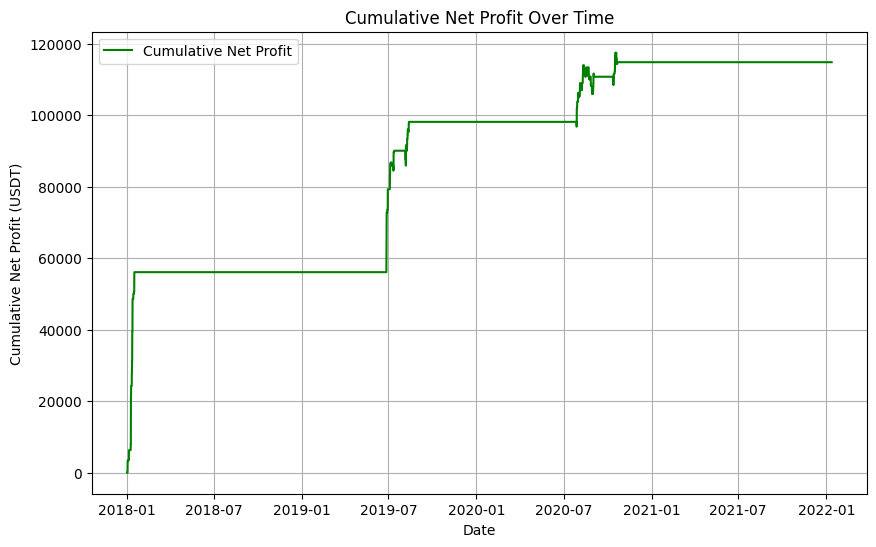

In [227]:
#df['Position']=-df['Position']
# Initialize variables for tracking trades and capital invested
df['trades']=0
df['num_trades']=0
trades = []
current_capital = initial_capital  # Track the current capital
prev_position = 0  # Track the current position (1 for long, -1 for short, 0 for neutral)
entry_price = None  # Track entry price for calculating profit/loss
brokerage = 0.1/100 #0.1%

# Iterate over the DataFrame to capture trade profits/losses
for i in range(1, len(df)):
    # Check if position changes
    if df['Position'].iloc[i] != prev_position:
        # Exiting long position
        if prev_position == 1:
            exit_price=(df['close'].iloc[i])*(1-brokerage)
            profit_loss = (exit_price - entry_price) * (current_capital / entry_price)
            trades.append(profit_loss)  # Append the realized profit/loss
            df.loc[i,'trades']=profit_loss
            df.loc[i,'num_trades']=current_capital / entry_price
            current_capital += profit_loss  # Update current capital
            prev_position = df['Position'].iloc[i]  # Update previoous position
            entry_price = None  # Reset entry price
        
        # Exiting short position
        elif prev_position == -1:
            exit_price=(df['close'].iloc[i])*(1+brokerage)
            profit_loss = (entry_price - exit_price) * (current_capital / entry_price)
            trades.append(profit_loss)  # Append the realized profit/loss
            df.loc[i,'trades']=profit_loss
            df.loc[i,'num_trades']=current_capital / entry_price
            current_capital += profit_loss  # Update current capital
            prev_position = df['Position'].iloc[i]  # Update previoous position
            entry_price = None  # Reset entry price
        
        # Entering long position
        if df['Position'].iloc[i] == 1:
            entry_price = (df['close'].iloc[i])*(1+brokerage)  # Capture entry price for long
            prev_position = 1  # Update to long position
        
        # Entering short position
        elif df['Position'].iloc[i] == -1:
            entry_price = (df['close'].iloc[i])*(1-brokerage)  # Capture entry price for short
            prev_position = -1  # Update to short position

winning_trades = df[df['trades'] > 0]
losing_trades = df[df['trades'] < 0]
# Sum the 'num_trades' column for all winning trades
num_winning_trades = winning_trades['num_trades'].sum()
num_losing_trades = losing_trades['num_trades'].sum()
# Count total trades and calculate other metrics
gross_profit = winning_trades['trades'].sum()
gross_loss = losing_trades['trades'].sum()

average_winning_trade = (winning_trades['trades'].sum())/(winning_trades['num_trades'].sum()) if num_winning_trades > 0 else 0
average_losing_trade = (losing_trades['trades'].sum())/(losing_trades['num_trades'].sum()) if num_losing_trades > 0 else 0
largest_winning_trade = (winning_trades['trades']/winning_trades['num_trades']).max() if num_winning_trades > 0 else 0
largest_losing_trade = (losing_trades['trades']/losing_trades['num_trades']).min() if num_losing_trades > 0 else 0
net_profit=gross_profit+gross_loss

# Calculate cumulative net profit over time for plotting
df['Cumulative_Profit_Loss'] = df['trades'].cumsum().fillna(0)  # Fill missing values with 0
df['Returns'] = (df['Cumulative_Profit_Loss']+100000).pct_change().fillna(0)

# Risk-free rate 
risk_free_rate = 0  # 2% annually
days_in_year = 365  # Approximate number of trading days in a year
daily_risk_free_rate = (1 + risk_free_rate) ** (1 / days_in_year) - 1
# Calculate average daily return and standard deviation of daily returns
average_return = df['Returns'].mean()
std_dev_return = df['Returns'].std()
# Calculate the Sharpe Ratio
sharpe_ratio = (average_return - daily_risk_free_rate) / std_dev_return

# Filter the negative returns (downside returns)
negative_returns = df[df['Returns'] < daily_risk_free_rate]['Returns']
# Calculate downside deviation (standard deviation of negative returns)
downside_deviation = negative_returns.std()
# Calculate the Sortino Ratio
sortino_ratio = (average_return - daily_risk_free_rate) / downside_deviation

df['Portfolio']=df['Cumulative_Profit_Loss']+100000
#Calculate the running maximum of the portfolio
df['Peak'] = df['Portfolio'].cummax()
#Calculate the drawdown
df['Drawdown'] = (df['Peak'] - df['Portfolio']) / df['Peak']
#Convert drawdown to percentage
df['Drawdown_pct'] = df['Drawdown'] * 100
# Find the maximum drawdown
max_drawdown = df['Drawdown_pct'].max()
drawdown=-(df['Peak'] - df['Portfolio']).max()
# Output all metrics
metrics = {
    "Gross Profit": gross_profit,
    "Net Profit": net_profit,
    "Gross Loss": gross_loss,
    "Total Closed Trades": num_winning_trades+num_losing_trades,
    "Number of Winning Trades": num_winning_trades,
    "Number of Losing Trades": num_losing_trades,
    "Average Winning Trade (USDT)": average_winning_trade,
    "Average Losing Trade (USDT)": average_losing_trade,
    "Largest Winning Trade (USDT)": largest_winning_trade,
    "Largest Losing Trade (USDT)": largest_losing_trade,
    "Max Drawdown": drawdown
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.2f}")

# Plot net profit over time
plt.figure(figsize=(10, 6))
plt.plot(df['datetime'], df['Cumulative_Profit_Loss'], label='Cumulative Net Profit', color='g')
plt.title('Cumulative Net Profit Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Net Profit (USDT)')
plt.grid(True)
plt.legend()
plt.show()